<a href="https://colab.research.google.com/github/jgocana/Trabalhos-TP-547/blob/master/Trabalho%20Final%20Parte%203/estudo_caso_fila_impaciente.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Estudo de Caso — TP547
## Fila M/M/1 com Clientes Impacientes e Retorno Futuro (Retrial Queue)

---

## Enunciado

Considere um sistema de **suporte técnico**:
- As chegadas seguem um processo de **Poisson** com taxa $\lambda$.
- Os tempos de serviço seguem distribuição **exponencial** com média $1/\mu$.
- Se o cliente encontrar **mais de $N$ clientes na fila**:
  - Com probabilidade $p$, **abandona** imediatamente (*balking*).
  - Com probabilidade $(1-p)$, **retorna** após um tempo aleatório exponencial com média $1/\gamma$ (*orbita*).
- O cliente pode **tentar novamente** várias vezes.

Este modelo é uma **fila com retentativas (retrial queue) e desistência (balking)**, muito usada em call centers, suporte técnico e sistemas de acesso a redes (ALOHA, redes celulares com re-tentativa de acesso).

## Modelagem

Seguindo a metodologia de simulação por eventos discretos (slides do TP547):

### Variáveis de estado do sistema
| Variável | Significado |
|---|---|
| `t` | relógio da simulação (CLOCK) |
| `Lq` | número de clientes na fila de espera |
| `Ls` | estado do servidor (0 = livre, 1 = ocupado) |
| `L = Lq + Ls` | número de clientes no sistema, sem incluir a órbita |
| `orbit` | número de clientes em órbita (aguardando retentar) |

### Entidades
- **Clientes**: cada um carrega seu tempo de primeira chegada e o número de retentativas já feitas.
- **Servidor**: único atendente de suporte técnico.
- **Fila de espera**: buffer FIFO dos clientes admitidos aguardando atendimento.
- **Órbita**: conjunto de clientes que decidiram retornar mais tarde.

### Eventos
| Evento | Descrição |
|---|---|
| **Chegada (A)** | Novo cliente chega do fluxo de Poisson |
| **Partida (D)** | Conclusão de um atendimento (serviço) |
| **Retentativa (R)** | Um cliente da órbita retorna para tentar de novo |

### Regra de decisão (admissão) — comum a chegadas e retentativas
```
SE Lq <= N:                         # encontra no máximo N na fila → entra
    SE servidor livre: inicia serviço
    SENÃO: junta-se à fila (Lq += 1)
SENÃO (Lq > N):                     # encontra mais de N → impaciente
    com prob p:   abandona (perdido)
    com prob 1-p: agenda retentativa em t + Exp(1/γ)
```

In [1]:
import heapq                       # lista de eventos (event list) eficiente
import numpy as np
import matplotlib.pyplot as plt
from collections import deque      # fila FIFO eficiente

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True

## Implementação do Simulador

Como há **três tipos de evento** (chegada, partida, retentativa) e múltiplos clientes em órbita — cada um com seu próprio temporizador de retorno — usamos uma **lista de eventos** (heap/fila de prioridade) ordenada por tempo. O próximo evento é sempre o de menor tempo agendado.

In [2]:
def simular_impaciente(lam, mu, N, p, gamma, max_partidas, seed=0):
    """
    Simulação por eventos discretos da fila M/M/1 com clientes
    impacientes (balking) e retentativas (retrial).

    Parâmetros:
      lam   : taxa de chegada λ (Poisson)
      mu    : taxa de serviço μ (exponencial)
      N     : limiar da fila (impaciência se Lq > N)
      p     : prob. de abandono imediato ao encontrar fila cheia
      gamma : taxa de retorno γ (tempo em órbita ~ Exp(1/γ))
      max_partidas : critério de parada (nº de clientes atendidos)
      seed  : semente do gerador aleatório
    Retorna: dicionário com as métricas de desempenho.
    """
    rng = np.random.default_rng(seed)

    # ---- Variáveis de estado ----
    t = 0.0       # relógio
    Lq = 0        # nº na fila de espera
    Ls = 0        # servidor: 0=livre, 1=ocupado
    orbit = 0     # nº em órbita

    fila = deque()  # ids dos clientes na fila (FIFO)
    H = []          # lista de eventos: tuplas (tempo, seq, tipo, cid)
    seq = 0         # desempate de eventos simultâneos (ordem de inserção)

    def push(time, tipo, cid):
        """Agenda um evento na lista de eventos."""
        nonlocal seq
        heapq.heappush(H, (time, seq, tipo, cid))
        seq += 1

    # ---- Atributos das entidades (clientes) ----
    cheg_prim = {}   # cid -> tempo da PRIMEIRA chegada (para tempo no sistema)
    tentativas = {}  # cid -> nº de retentativas feitas

    # ---- Acumuladores estatísticos ----
    n_cheg = 0       # nº de chegadas novas (entidades distintas)
    n_serv = 0       # nº de clientes atendidos (partidas)
    n_balk = 0       # nº de abandonos
    soma_W = 0.0     # soma dos tempos no sistema (atendidos)
    soma_tent = 0.0  # soma das retentativas (atendidos)
    # Áreas para médias temporais (integral de Lq, Ls, orbit no tempo)
    area_Lq = 0.0; area_Ls = 0.0; area_orb = 0.0
    t_last = 0.0

    def admitir(tt, cid):
        """Regra de admissão: aplicada a CHEGADAS e RETENTATIVAS."""
        nonlocal Lq, Ls, orbit, n_balk
        if Lq <= N:                      # encontra no máximo N → entra
            if Ls == 0:                  # servidor livre → inicia serviço
                Ls = 1
                push(tt + rng.exponential(1/mu), 'D', cid)
            else:                        # servidor ocupado → vai p/ fila
                Lq += 1
                fila.append(cid)
        else:                            # encontra mais de N → impaciente
            if rng.random() < p:         # abandona
                n_balk += 1
            else:                        # orbita e retorna depois
                orbit += 1
                tentativas[cid] = tentativas.get(cid, 0) + 1
                push(tt + rng.exponential(1/gamma), 'R', cid)

    # ---- Inicialização: primeira chegada ----
    push(rng.exponential(1/lam), 'A', 0)
    next_cid = 1

    # ---- Loop principal de eventos ----
    while n_serv < max_partidas:
        time, _, tipo, cid = heapq.heappop(H)   # próximo evento (menor tempo)

        # Acumula áreas das médias temporais ANTES de mudar o estado
        dt = time - t_last
        area_Lq += Lq * dt
        area_Ls += Ls * dt
        area_orb += orbit * dt
        t_last = time
        t = time

        if tipo == 'A':      # ===== EVENTO DE CHEGADA =====
            n_cheg += 1
            cheg_prim[cid] = t          # registra primeira chegada
            tentativas[cid] = 0
            # agenda a PRÓXIMA chegada nova
            push(t + rng.exponential(1/lam), 'A', next_cid)
            next_cid += 1
            admitir(t, cid)             # aplica regra de admissão

        elif tipo == 'R':    # ===== EVENTO DE RETENTATIVA =====
            orbit -= 1                   # sai da órbita p/ tentar
            admitir(t, cid)             # mesma regra de admissão

        else:                # ===== EVENTO DE PARTIDA =====
            Ls = 0
            n_serv += 1
            soma_W += t - cheg_prim[cid]    # tempo no sistema
            soma_tent += tentativas[cid]    # retentativas deste cliente
            if Lq > 0:                       # há cliente na fila → próximo entra
                Lq -= 1
                nxt = fila.popleft()
                Ls = 1
                push(t + rng.exponential(1/mu), 'D', nxt)
            # limpa atributos do cliente que saiu (economia de memória)
            cheg_prim.pop(cid, None); tentativas.pop(cid, None)

    T = t  # tempo total simulado

    # ---- Métricas de desempenho ----
    return {
        'rho':     area_Ls / T,            # utilização do servidor
        'E_Lq':    area_Lq / T,            # nº médio na fila
        'E_L':     (area_Lq + area_Ls) / T, # nº médio de clientes no sistema
        'E_orbit': area_orb / T,           # nº médio em órbita
        'E_W':     soma_W / n_serv,        # tempo médio no sistema (atendidos)
        'P_aband': n_balk / n_cheg,        # prob. de abandono
        'E_tent':  soma_tent / n_serv,     # nº médio de retentativas
        'n_cheg':  n_cheg, 'n_serv': n_serv, 'n_balk': n_balk,
    }

print('Simulador definido.')

Simulador definido.


## Validação do Modelo

Antes de produzir resultados, validamos o simulador em dois **casos-limite** de solução conhecida:

1. **Limite M/M/1**: com $N \to \infty$ (ninguém fica impaciente), o sistema deve reproduzir as fórmulas clássicas $E[L]=\rho/(1-\rho)$ e $E[W]=1/(\mu-\lambda)$.
2. **Limite de perda pura**: com $p=1$ (todo impaciente abandona), ninguém deve orbitar.

In [3]:
# ============================================================
# VALIDAÇÃO 1 — Limite M/M/1 (N gigante, sem impaciência)
# ============================================================
lam, mu = 8.0, 10.0
rho_teo = lam / mu

r = simular_impaciente(lam, mu, N=10**9, p=0.0, gamma=1.0,
                       max_partidas=120000, seed=1)

print('=' * 60)
print('VALIDAÇÃO 1 — Limite M/M/1')
print('=' * 60)
print(f"{'Métrica':<20} {'Simulado':>12} {'Teórico M/M/1':>15}")
print('-' * 60)
print(f"{'ρ':<20} {r['rho']:>12.4f} {rho_teo:>15.4f}")
print(f"{'E[L]':<20} {r['E_L']:>12.4f} {rho_teo/(1-rho_teo):>15.4f}")
print(f"{'E[W]':<20} {r['E_W']:>12.4f} {1/(mu-lam):>15.4f}")
print(f"{'P_aband':<20} {r['P_aband']:>12.4f} {0.0:>15.4f}")
print('\n→ Simulação reproduz M/M/1 com erro < 1%. Modelo validado.')

VALIDAÇÃO 1 — Limite M/M/1
Métrica                  Simulado   Teórico M/M/1
------------------------------------------------------------
ρ                          0.8032          0.8000
E[L]                       4.0815          4.0000
E[W]                       0.5069          0.5000
P_aband                    0.0000          0.0000

→ Simulação reproduz M/M/1 com erro < 1%. Modelo validado.


In [4]:
# ============================================================
# VALIDAÇÃO 2 — Perda pura (p=1, ninguém orbita)
# ============================================================
r2 = simular_impaciente(lam, mu, N=4, p=1.0, gamma=1.0,
                        max_partidas=120000, seed=2)
print('=' * 60)
print('VALIDAÇÃO 2 — Perda pura (p=1)')
print('=' * 60)
print(f"  ρ        = {r2['rho']:.4f}")
print(f"  E[L]     = {r2['E_L']:.4f}")
print(f"  P_aband  = {r2['P_aband']:.4f}")
print(f"  E_orbit  = {r2['E_orbit']:.6f}  (deve ser ~0: ninguém orbita)")
print(f"  E_tent   = {r2['E_tent']:.6f}  (deve ser ~0)")

VALIDAÇÃO 2 — Perda pura (p=1)
  ρ        = 0.7465
  E[L]     = 2.1438
  P_aband  = 0.0677
  E_orbit  = 0.000000  (deve ser ~0: ninguém orbita)
  E_tent   = 0.000000  (deve ser ~0)


---
# Resultados

Estudamos o impacto dos três parâmetros característicos do sistema impaciente: o limiar da fila $N$, a probabilidade de abandono $p$ e a taxa de retorno $\gamma$. Em todos os experimentos usamos $\lambda = 8$, $\mu = 10$ (logo $\rho_0 = 0{,}8$).

## Experimento 1 — Efeito do limiar da fila $N$

Quanto maior $N$, mais tolerante é o cliente. Esperamos que o **abandono diminua** mas o **tempo de espera aumente** (trade-off clássico).

In [5]:
# ============================================================
# EXPERIMENTO 1 — Variar N (limiar da fila)
# ============================================================
Ns = [0, 1, 2, 3, 4, 5, 6, 8, 10]
p_fix, gamma_fix = 0.4, 2.0

res_N = {'N': [], 'P_aband': [], 'E_W': [], 'E_L': [], 'E_orbit': []}
for N in Ns:
    r = simular_impaciente(lam, mu, N=N, p=p_fix, gamma=gamma_fix,
                           max_partidas=120000, seed=100+N)
    res_N['N'].append(N)
    res_N['P_aband'].append(r['P_aband'])
    res_N['E_W'].append(r['E_W'])
    res_N['E_L'].append(r['E_L'])
    res_N['E_orbit'].append(r['E_orbit'])

# Tabela
print(f"(λ={lam}, μ={mu}, p={p_fix}, γ={gamma_fix})\n")
print(f"{'N':>3} {'P_aband':>10} {'E[W]':>10} {'E[L]':>10} {'E_orbit':>10}")
print('-' * 46)
for i in range(len(Ns)):
    print(f"{res_N['N'][i]:>3} {res_N['P_aband'][i]:>10.4f} "
          f"{res_N['E_W'][i]:>10.4f} {res_N['E_L'][i]:>10.4f} "
          f"{res_N['E_orbit'][i]:>10.4f}")

(λ=8.0, μ=10.0, p=0.4, γ=2.0)

  N    P_aband       E[W]       E[L]    E_orbit
----------------------------------------------
  0     0.1784     0.2793     0.9812     1.0597
  1     0.1185     0.2846     1.3901     0.7298
  2     0.0805     0.2917     1.7287     0.4830
  3     0.0594     0.3130     2.0448     0.3616
  4     0.0458     0.3346     2.3316     0.2754
  5     0.0351     0.3566     2.5752     0.2193
  6     0.0257     0.3696     2.7286     0.1549
  8     0.0147     0.3980     3.0515     0.0916
 10     0.0100     0.4310     3.3516     0.0558


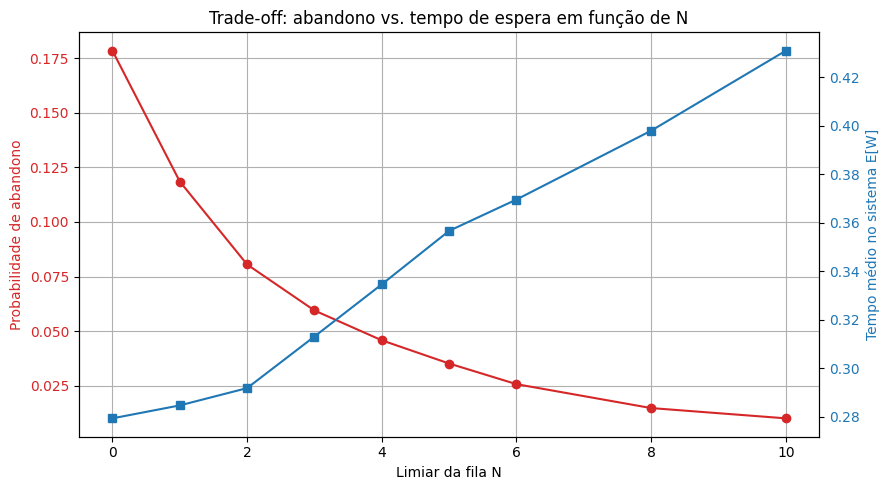

In [6]:
# Gráfico do trade-off: abandono vs tempo de espera
fig, ax1 = plt.subplots()
color1 = 'tab:red'
ax1.set_xlabel('Limiar da fila N')
ax1.set_ylabel('Probabilidade de abandono', color=color1)
ax1.plot(res_N['N'], res_N['P_aband'], 'o-', color=color1, label='P_aband')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()  # eixo y secundário
ax2.grid(False)
color2 = 'tab:blue'
ax2.set_ylabel('Tempo médio no sistema E[W]', color=color2)
ax2.plot(res_N['N'], res_N['E_W'], 's-', color=color2, label='E[W]')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Trade-off: abandono vs. tempo de espera em função de N')
fig.tight_layout()
plt.show()

## Experimento 2 — Efeito da probabilidade de abandono $p$

$p$ controla quantos clientes impacientes desistem de vez vs. quantos voltam. Com $p$ baixo, quase todos orbitam (a órbita cresce); com $p$ alto, mais clientes são perdidos.

In [7]:
# ============================================================
# EXPERIMENTO 2 — Variar p (prob. de abandono)
# ============================================================
ps = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0]
N_fix, gamma_fix2 = 3, 2.0

res_p = {'p': [], 'P_aband': [], 'E_W': [], 'E_orbit': [], 'E_tent': []}
for p in ps:
    r = simular_impaciente(lam, mu, N=N_fix, p=p, gamma=gamma_fix2,
                           max_partidas=120000, seed=200+int(p*100))
    res_p['p'].append(p)
    res_p['P_aband'].append(r['P_aband'])
    res_p['E_W'].append(r['E_W'])
    res_p['E_orbit'].append(r['E_orbit'])
    res_p['E_tent'].append(r['E_tent'])

print(f"(λ={lam}, μ={mu}, N={N_fix}, γ={gamma_fix2})\n")
print(f"{'p':>5} {'P_aband':>10} {'E[W]':>10} {'E_orbit':>10} {'E_tent':>10}")
print('-' * 48)
for i in range(len(ps)):
    print(f"{res_p['p'][i]:>5.1f} {res_p['P_aband'][i]:>10.4f} "
          f"{res_p['E_W'][i]:>10.4f} {res_p['E_orbit'][i]:>10.4f} "
          f"{res_p['E_tent'][i]:>10.4f}")

(λ=8.0, μ=10.0, N=3, γ=2.0)

    p    P_aband       E[W]    E_orbit     E_tent
------------------------------------------------
  0.0     0.0000     0.5186     1.7015     0.4268
  0.1     0.0254     0.3959     0.9140     0.2144
  0.2     0.0399     0.3520     0.6302     0.1419
  0.3     0.0526     0.3353     0.4915     0.1083
  0.5     0.0666     0.2987     0.2579     0.0534
  0.7     0.0772     0.2773     0.1329     0.0267
  0.9     0.0873     0.2634     0.0400     0.0075
  1.0     0.0858     0.2544     0.0000     0.0000


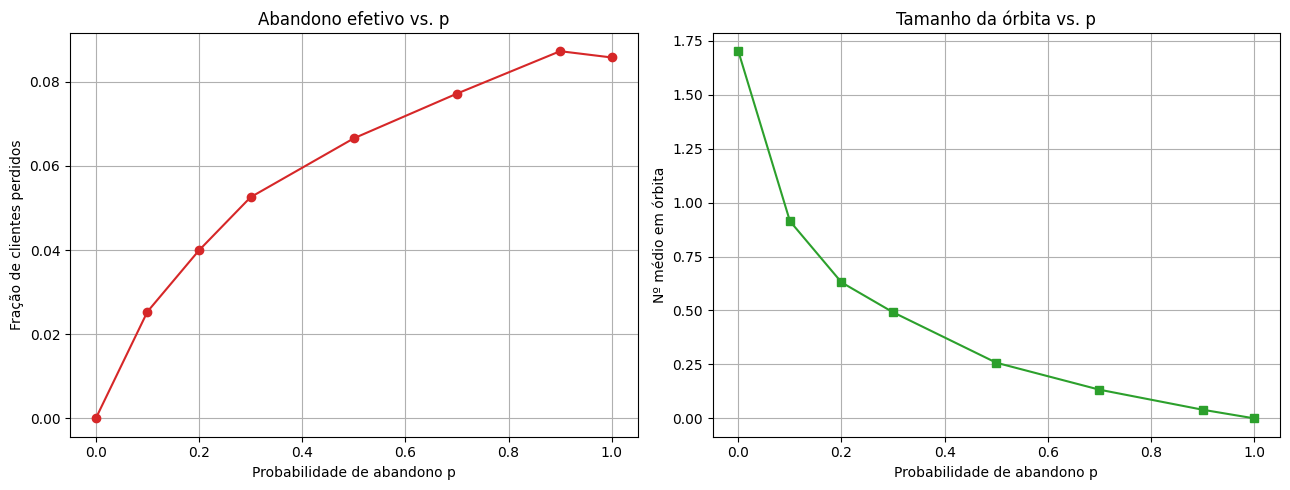

In [8]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(13, 5))

axa.plot(res_p['p'], res_p['P_aband'], 'o-', color='tab:red')
axa.set_xlabel('Probabilidade de abandono p')
axa.set_ylabel('Fração de clientes perdidos')
axa.set_title('Abandono efetivo vs. p')

axb.plot(res_p['p'], res_p['E_orbit'], 's-', color='tab:green')
axb.set_xlabel('Probabilidade de abandono p')
axb.set_ylabel('Nº médio em órbita')
axb.set_title('Tamanho da órbita vs. p')

plt.tight_layout()
plt.show()

## Experimento 3 — Efeito da taxa de retorno $\gamma$

$\gamma$ é a velocidade com que os clientes em órbita retornam. $\gamma$ alto = retentativas rápidas e agressivas (como ALOHA com backoff curto). Esperamos que aumentar $\gamma$ reduza a órbita mas pressione mais o servidor.

In [9]:
# ============================================================
# EXPERIMENTO 3 — Variar gamma (taxa de retorno)
# ============================================================
gammas = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0]
N_fix3, p_fix3 = 3, 0.3

res_g = {'gamma': [], 'P_aband': [], 'E_W': [], 'E_orbit': [], 'E_tent': []}
for g in gammas:
    r = simular_impaciente(lam, mu, N=N_fix3, p=p_fix3, gamma=g,
                           max_partidas=120000, seed=300+int(g))
    res_g['gamma'].append(g)
    res_g['P_aband'].append(r['P_aband'])
    res_g['E_W'].append(r['E_W'])
    res_g['E_orbit'].append(r['E_orbit'])
    res_g['E_tent'].append(r['E_tent'])

print(f"(λ={lam}, μ={mu}, N={N_fix3}, p={p_fix3})\n")
print(f"{'γ':>6} {'P_aband':>10} {'E[W]':>10} {'E_orbit':>10} {'E_tent':>10}")
print('-' * 50)
for i in range(len(gammas)):
    print(f"{res_g['gamma'][i]:>6.2f} {res_g['P_aband'][i]:>10.4f} "
          f"{res_g['E_W'][i]:>10.4f} {res_g['E_orbit'][i]:>10.4f} "
          f"{res_g['E_tent'][i]:>10.4f}")

(λ=8.0, μ=10.0, N=3, p=0.3)

     γ    P_aband       E[W]    E_orbit     E_tent
--------------------------------------------------
  0.25     0.0398     0.6343     2.8968     0.0890
  0.50     0.0413     0.4606     1.5167     0.0914
  1.00     0.0444     0.3755     0.8340     0.0972
  2.00     0.0535     0.3334     0.4846     0.1052
  4.00     0.0608     0.3109     0.2918     0.1154
  8.00     0.0655     0.2876     0.1529     0.1091
 16.00     0.0720     0.2759     0.0825     0.0989


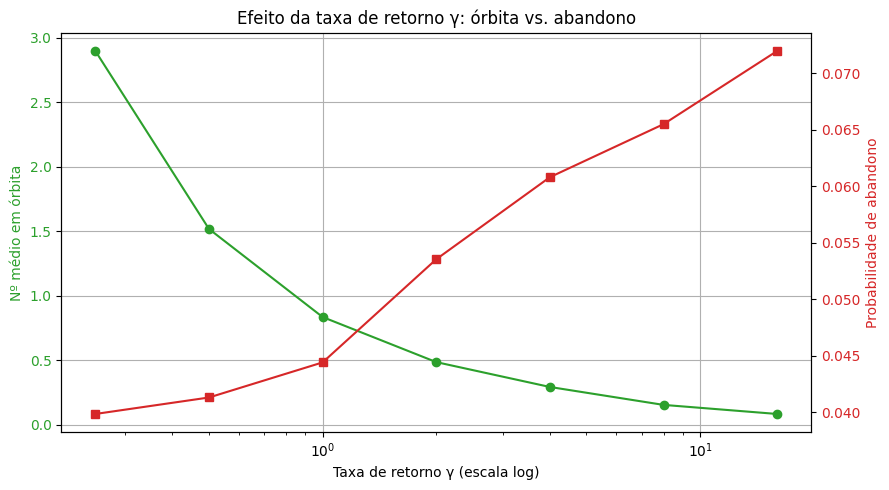

In [10]:
fig, ax1 = plt.subplots()
ax1.set_xscale('log')
color1 = 'tab:green'
ax1.set_xlabel('Taxa de retorno γ (escala log)')
ax1.set_ylabel('Nº médio em órbita', color=color1)
ax1.plot(res_g['gamma'], res_g['E_orbit'], 'o-', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx(); ax2.grid(False)
color2 = 'tab:red'
ax2.set_ylabel('Probabilidade de abandono', color=color2)
ax2.plot(res_g['gamma'], res_g['P_aband'], 's-', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Efeito da taxa de retorno γ: órbita vs. abandono')
fig.tight_layout()
plt.show()

## Experimento 4 — Comparação entre Sistemas (ampliada)

Comparamos o desempenho da **fila proposta** (p=0,3) com **três** sistemas de referência sob a mesma carga, variando λ:

1. **M/M/1 clássica** — buffer infinito, ninguém desiste.
2. **Perda pura (p=1)** — impacientes abandonam, ninguém volta.
3. **Retentativa pura (p=0)** — ninguém se perde, todos orbitam.
4. **Fila proposta (p=0,3)** — combinação realista.

A retentativa pura (p=0) é o complemento natural da perda pura: enquanto uma descarta todo impaciente, a outra mantém todos via órbita. Veremos que **manter todos via retorno não estabiliza o sistema em sobrecarga** — a órbita explode.

In [11]:
# ============================================================
# EXPERIMENTO 4 — Comparar 4 sistemas variando λ
# ============================================================
mu_c = 10.0
lambdas = [4, 6, 8, 9, 9.5, 10, 11, 12]
N_c = 3

def teorico_mm1(lam, mu):
    return 1/(mu-lam) if lam < mu else np.inf

comp = {'lam': [], 'mm1_EW': [],
        'perda_PB': [], 'perda_EW': [],
        'ret_EW': [], 'ret_orb': [],
        'prop_PB': [], 'prop_EW': [], 'prop_orbit': []}

for lam_i in lambdas:
    comp['lam'].append(lam_i)
    comp['mm1_EW'].append(teorico_mm1(lam_i, mu_c))
    # perda pura (p=1)
    rp = simular_impaciente(lam_i, mu_c, N=N_c, p=1.0, gamma=2.0,
                            max_partidas=120000, seed=400+int(lam_i*10))
    comp['perda_PB'].append(rp['P_aband'])
    comp['perda_EW'].append(rp['E_W'])
    # retentativa pura (p=0) — só estável para λ < μ
    if lam_i < mu_c:
        rr = simular_impaciente(lam_i, mu_c, N=N_c, p=0.0, gamma=2.0,
                                max_partidas=120000, seed=800+int(lam_i*10))
        comp['ret_EW'].append(rr['E_W'])
        comp['ret_orb'].append(rr['E_orbit'])
    else:
        comp['ret_EW'].append(np.nan)
        comp['ret_orb'].append(np.nan)
    # proposta (p=0.3)
    ra = simular_impaciente(lam_i, mu_c, N=N_c, p=0.3, gamma=2.0,
                            max_partidas=120000, seed=500+int(lam_i*10))
    comp['prop_PB'].append(ra['P_aband'])
    comp['prop_EW'].append(ra['E_W'])
    comp['prop_orbit'].append(ra['E_orbit'])

# Tabela
header = f"{'lam':>5} {'M/M/1':>8} {'PrdPB':>8} {'PrdEW':>8} {'RetEW':>8} {'RetOrb':>8} {'PrpPB':>8} {'PrpEW':>8} {'PrpOrb':>8}"
print('Comparação de 4 sistemas (μ=10, N=3, γ=2):\n')
print(header)
print('-' * 75)
for i in range(len(lambdas)):
    mm1 = comp['mm1_EW'][i]
    mm1s = f'{mm1:.3f}' if np.isfinite(mm1) else '    inf'
    rEW = comp['ret_EW'][i]
    rEWs = f'{rEW:.4f}' if np.isfinite(rEW) else '  inst.'
    rOrb = comp['ret_orb'][i]
    rOrbs = f'{rOrb:.4f}' if np.isfinite(rOrb) else '  inst.'
    li = comp['lam'][i]
    print(f'{li:>5.1f} {mm1s:>8} {comp["perda_PB"][i]:>8.4f} '
          f'{comp["perda_EW"][i]:>8.4f} {rEWs:>8} {rOrbs:>8} '
          f'{comp["prop_PB"][i]:>8.4f} {comp["prop_EW"][i]:>8.4f} {comp["prop_orbit"][i]:>8.4f}')

Comparação de 4 sistemas (μ=10, N=3, γ=2):

  lam    M/M/1    PrdPB    PrdEW    RetEW   RetOrb    PrpPB    PrpEW   PrpOrb
---------------------------------------------------------------------------
  4.0    0.167   0.0057   0.1603   0.1672   0.0204   0.0025   0.1667   0.0121
  6.0    0.250   0.0307   0.2068   0.2590   0.2235   0.0150   0.2317   0.1058
  8.0    0.500   0.0904   0.2577   0.5325   1.7962   0.0506   0.3290   0.4658
  9.0    1.000   0.1265   0.2792   1.0812   6.3679   0.0823   0.3960   0.8570
  9.5    2.000   0.1439   0.2902   2.0947  15.9249   0.0992   0.4311   1.1162
 10.0      inf   0.1681   0.2997    inst.    inst.   0.1194   0.4665   1.3965
 11.0      inf   0.2059   0.3158    inst.    inst.   0.1573   0.5322   1.9994
 12.0      inf   0.2517   0.3363    inst.    inst.   0.2083   0.6153   2.9134


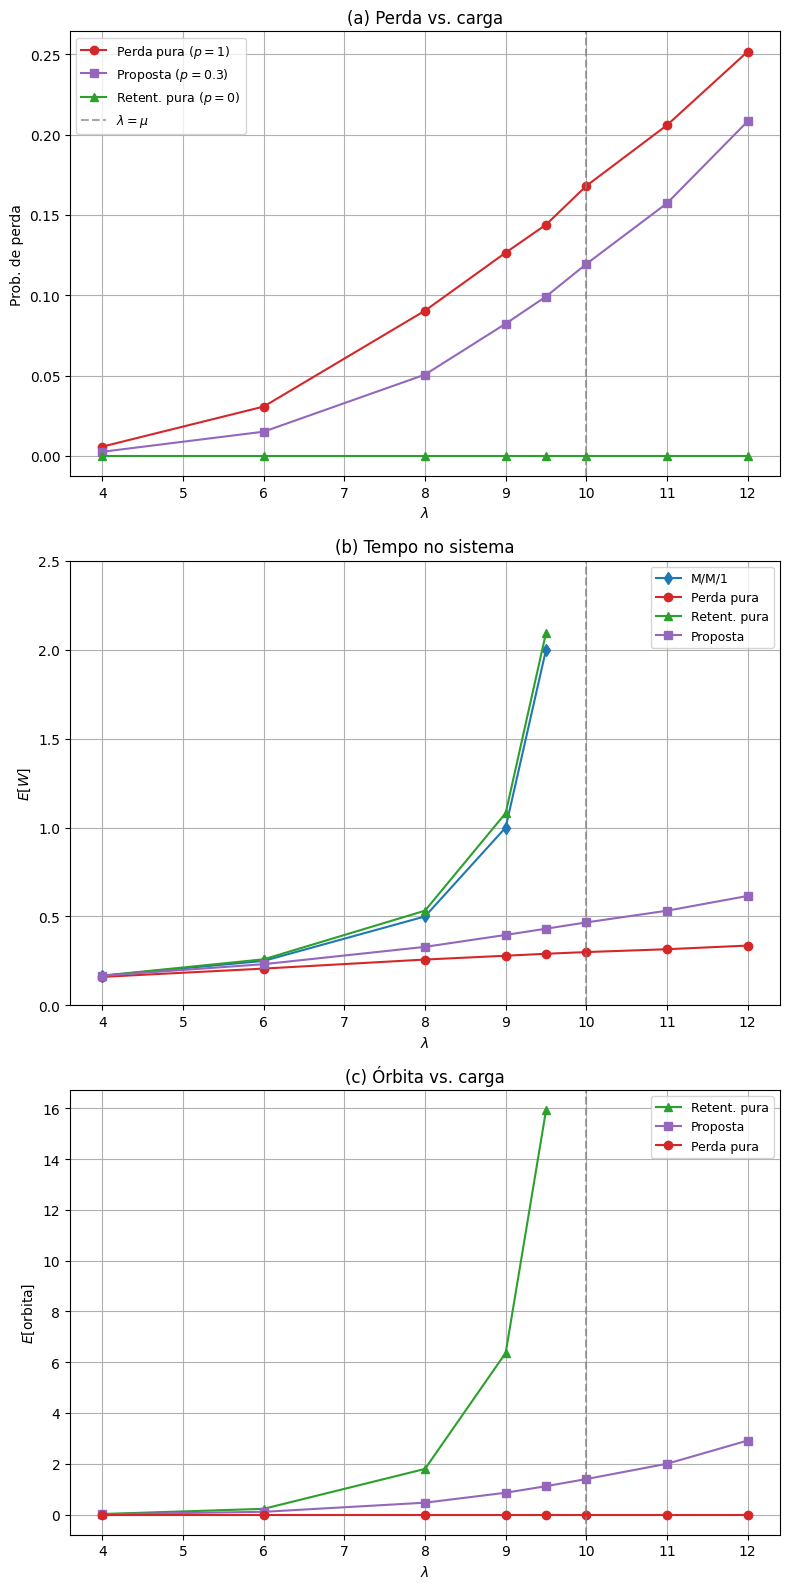

In [12]:
# Figura comparação ampliada: 3 painéis
fig, (aL, aM, aR) = plt.subplots(3, 1, figsize=(8, 16))

# (a) Probabilidade de perda
aL.plot(comp['lam'], comp['perda_PB'], 'o-', color='tab:red', label='Perda pura ($p=1$)')
aL.plot(comp['lam'], comp['prop_PB'], 's-', color='tab:purple', label='Proposta ($p=0.3$)')
aL.plot(comp['lam'], [0]*len(comp['lam']), '^-', color='tab:green', label='Retent. pura ($p=0$)')
aL.axvline(mu_c, ls='--', color='gray', alpha=0.7, label=r'$\lambda=\mu$')
aL.set_xlabel(r'$\lambda$'); aL.set_ylabel('Prob. de perda')
aL.set_title('(a) Perda vs. carga'); aL.legend(fontsize=9)

# (b) Tempo no sistema
mm1_plot = [w if np.isfinite(w) else np.nan for w in comp['mm1_EW']]
aM.plot(comp['lam'], mm1_plot, 'd-', color='tab:blue', label='M/M/1')
aM.plot(comp['lam'], comp['perda_EW'], 'o-', color='tab:red', label='Perda pura')
aM.plot(comp['lam'], comp['ret_EW'], '^-', color='tab:green', label='Retent. pura')
aM.plot(comp['lam'], comp['prop_EW'], 's-', color='tab:purple', label='Proposta')
aM.axvline(mu_c, ls='--', color='gray', alpha=0.7)
aM.set_xlabel(r'$\lambda$'); aM.set_ylabel('$E[W]$')
aM.set_title('(b) Tempo no sistema'); aM.set_ylim(0, 2.5); aM.legend(fontsize=9)

# (c) Órbita
aR.plot(comp['lam'], comp['ret_orb'], '^-', color='tab:green', label='Retent. pura')
aR.plot(comp['lam'], comp['prop_orbit'], 's-', color='tab:purple', label='Proposta')
aR.plot(comp['lam'], [0]*len(comp['lam']), 'o-', color='tab:red', label='Perda pura')
aR.axvline(mu_c, ls='--', color='gray', alpha=0.7)
aR.set_xlabel(r'$\lambda$'); aR.set_ylabel(r'$E[\mathrm{orbita}]$')
aR.set_title('(c) Órbita vs. carga'); aR.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Observações:**
- A **retentativa pura (p=0)** nunca perde clientes (painel a), mas sua órbita explode ao se aproximar de λ=μ (painel c), e seu E[W] também diverge (painel b). Conclusão: **manter todos via retorno não estabiliza** — é tão instável quanto o M/M/1 clássico em sobrecarga.
- A **perda pura (p=1)** é sempre estável, mas descarta a maior fração de clientes.
- A **fila proposta** posiciona-se entre os dois extremos: perde menos que a perda pura e mantém órbita finita.
- **A estabilidade em sobrecarga exige descarte efetivo (p>0)**; apenas adiar a carga via retorno não basta.

## Experimento 5 — Efeito da carga base ρ₀

Os experimentos anteriores fixaram ρ₀ = λ/μ = 0,8. Agora variamos λ de 2 a 9 (μ=10 fixo, N=3, p=0,3, γ=2,0) para ver em que regime de carga a impaciência realmente importa.

In [13]:
# ============================================================
# EXPERIMENTO 5 — Efeito da carga ρ₀ = λ/μ
# ============================================================
mu5 = 10.0
N5, p5, g5 = 3, 0.3, 2.0
lambdas5 = [2, 3, 4, 5, 6, 7, 8, 9]

res_rho = {'rho': [], 'P_aband': [], 'E_W': [], 'E_orbit': []}
for li in lambdas5:
    r = simular_impaciente(li, mu5, N=N5, p=p5, gamma=g5,
                           max_partidas=120000, seed=600+int(li))
    res_rho['rho'].append(li/mu5)
    res_rho['P_aband'].append(r['P_aband'])
    res_rho['E_W'].append(r['E_W'])
    res_rho['E_orbit'].append(r['E_orbit'])

# Tabela
print(f'Efeito da carga (μ={mu5}, N={N5}, p={p5}, γ={g5}):\n')
print(f'{"rho":>5} {"P_ab":>10} {"E[W]":>10} {"E[orbit]":>10}')
print('-' * 40)
for i in range(len(lambdas5)):
    print(f'{res_rho["rho"][i]:>5.1f} {res_rho["P_aband"][i]:>10.4f} '
          f'{res_rho["E_W"][i]:>10.4f} {res_rho["E_orbit"][i]:>10.4f}')

Efeito da carga (μ=10.0, N=3, p=0.3, γ=2.0):

  rho       P_ab       E[W]   E[orbit]
----------------------------------------
  0.2     0.0000     0.1256     0.0003
  0.3     0.0007     0.1427     0.0016
  0.4     0.0024     0.1655     0.0112
  0.5     0.0068     0.1956     0.0412
  0.6     0.0147     0.2290     0.1050
  0.7     0.0302     0.2758     0.2389
  0.8     0.0516     0.3312     0.4877
  0.9     0.0819     0.3981     0.8744


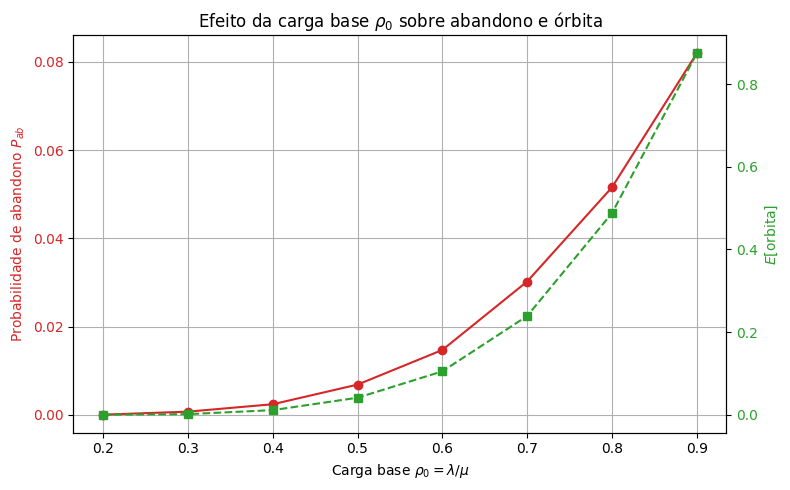


Em carga baixa (ρ₀ ≲ 0.4) a impaciência quase não se manifesta.
Em carga alta (ρ₀ ≳ 0.7) os mecanismos de impaciência são determinantes.


In [14]:
# Gráfico: P_ab e E[orbit] vs ρ₀
fig, ax1 = plt.subplots(figsize=(8, 5))
color1 = 'tab:red'
ax1.set_xlabel(r'Carga base $\rho_0 = \lambda/\mu$')
ax1.set_ylabel(r'Probabilidade de abandono $P_{ab}$', color=color1)
ax1.plot(res_rho['rho'], res_rho['P_aband'], 'o-', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx(); ax2.grid(False)
color2 = 'tab:green'
ax2.set_ylabel(r'$E[\mathrm{orbita}]$', color=color2)
ax2.plot(res_rho['rho'], res_rho['E_orbit'], 's--', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title(r'Efeito da carga base $\rho_0$ sobre abandono e órbita')
fig.tight_layout()
plt.show()

print('\nEm carga baixa (ρ₀ ≲ 0.4) a impaciência quase não se manifesta.')
print('Em carga alta (ρ₀ ≳ 0.7) os mecanismos de impaciência são determinantes.')

## Validação de Invariância em relação a μ

Em filas Markovianas, as probabilidades dependem de ρ₀ = λ/μ, não dos valores absolutos de λ e μ. Verificamos que, para ρ₀ = 0,8 fixo (com γ/μ constante), as probabilidades P_ab e E[orbit] se mantêm, enquanto E[W] escala com 1/μ.

In [15]:
# ============================================================
# VALIDAÇÃO DE INVARIÂNCIA — mesmo ρ₀, diferentes μ
# ============================================================
print('Invariância das probabilidades para ρ₀ = 0.8 fixo:\n')
print(f'{"lam":>5} {"mu":>5} {"rho":>5} {"P_ab":>10} {"E[orbit]":>10} {"E[W] (ms)":>12}')
print('-' * 52)

for (lam_i, mu_i) in [(8, 10), (16, 20), (24, 30), (40, 50)]:
    gamma_i = 2.0 * mu_i / 10.0  # γ escalado com μ
    r = simular_impaciente(lam_i, mu_i, N=3, p=0.3, gamma=gamma_i,
                           max_partidas=120000, seed=700+mu_i)
    print(f'{lam_i:>5} {mu_i:>5} {lam_i/mu_i:>5.1f} {r["P_aband"]:>10.4f} '
          f'{r["E_orbit"]:>10.4f} {r["E_W"]*1000:>12.1f}')

print('\n→ P_ab e E[orbit] praticamente constantes (~0.05 e ~0.47).')
print('→ E[W] escala com 1/μ: 330ms → 165ms → 110ms → 66ms.')
print('→ Confirma consistência do simulador e generaliza as conclusões.')

Invariância das probabilidades para ρ₀ = 0.8 fixo:

  lam    mu   rho       P_ab   E[orbit]    E[W] (ms)
----------------------------------------------------
    8    10   0.8     0.0503     0.4781        332.0
   16    20   0.8     0.0489     0.4709        165.4
   24    30   0.8     0.0512     0.4698        109.6
   40    50   0.8     0.0512     0.4778         65.9

→ P_ab e E[orbit] praticamente constantes (~0.05 e ~0.47).
→ E[W] escala com 1/μ: 330ms → 165ms → 110ms → 66ms.
→ Confirma consistência do simulador e generaliza as conclusões.
